1. Завантажити та створити DataFrame:

In [ ]:
import pandas as pd
import numpy as np
tv
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import confusion_matrix

In [ ]:
iris = load_iris()

# Виведення опису даних
print(iris.DESCR)
# Виведення ознак
print("Ознаки (features):", iris.feature_names)
# Виведення цільових міток
print("Мітки (target):", iris.target_names)
# Виведення розмірності даних
print("Розмірність даних:", iris.data.shape)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

#df.head()
df.groupby('species', group_keys=False).head(5).reset_index(drop=False)

,index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,0,5.1,3.5,1.4,0.2,0,setosa
1,1,4.9,3.0,1.4,0.2,0,setosa
2,2,4.7,3.2,1.3,0.2,0,setosa
3,3,4.6,3.1,1.5,0.2,0,setosa
4,4,5.0,3.6,1.4,0.2,0,setosa
5,50,7.0,3.2,4.7,1.4,1,versicolor
6,51,6.4,3.2,4.5,1.5,1,versicolor
7,52,6.9,3.1,4.9,1.5,1,versicolor
8,53,5.5,2.3,4.0,1.3,1,versicolor
9,54,6.5,2.8,4.6,1.5,1,versicolor


Кількість спостережень на клас

In [ ]:
df.target.value_counts()

,count
target,
0,50
1,50
2,50


2. Отримати базові статистичні характеристики:

In [ ]:
print("Статистика:")
df.describe()

Статистика:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000,1.206667
std,0.828066,0.435866,1.765298,0.762238,0.819232,0.796778
min,4.300000,2.000000,1.000000,0.100000,0.000000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000,1.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000,2.000000


3. Візуалізувати розподілення спостережень за класами:

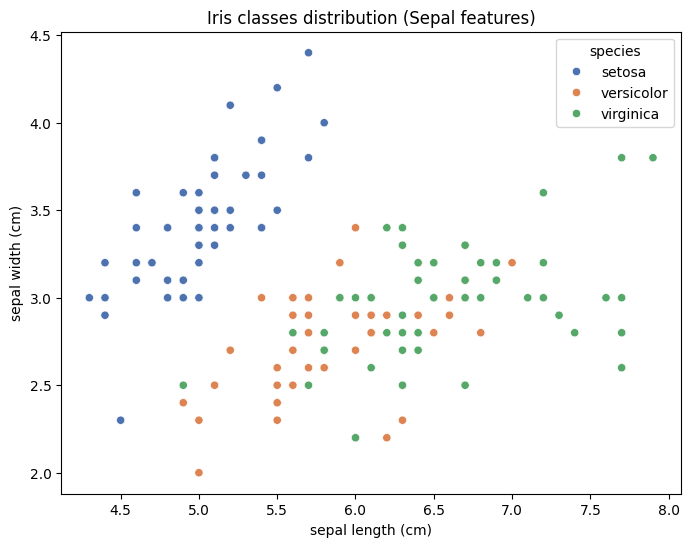

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='species',
    palette='deep'
)

plt.title("Iris classes distribution (Sepal features)")
plt.show()

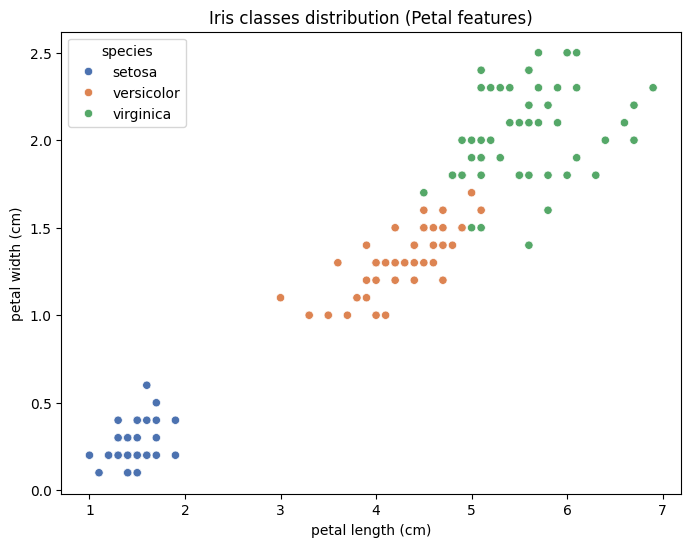

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    palette='deep'
)

plt.title("Iris classes distribution (Petal features)")
plt.show()

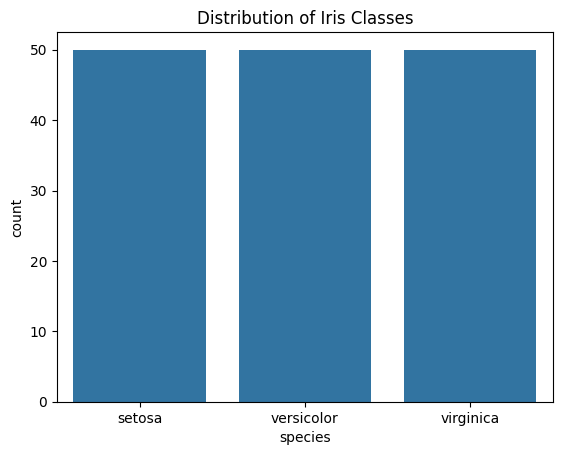

In [ ]:
sns.countplot(x='species', data=df)
plt.title("Distribution of Iris Classes")
plt.show()

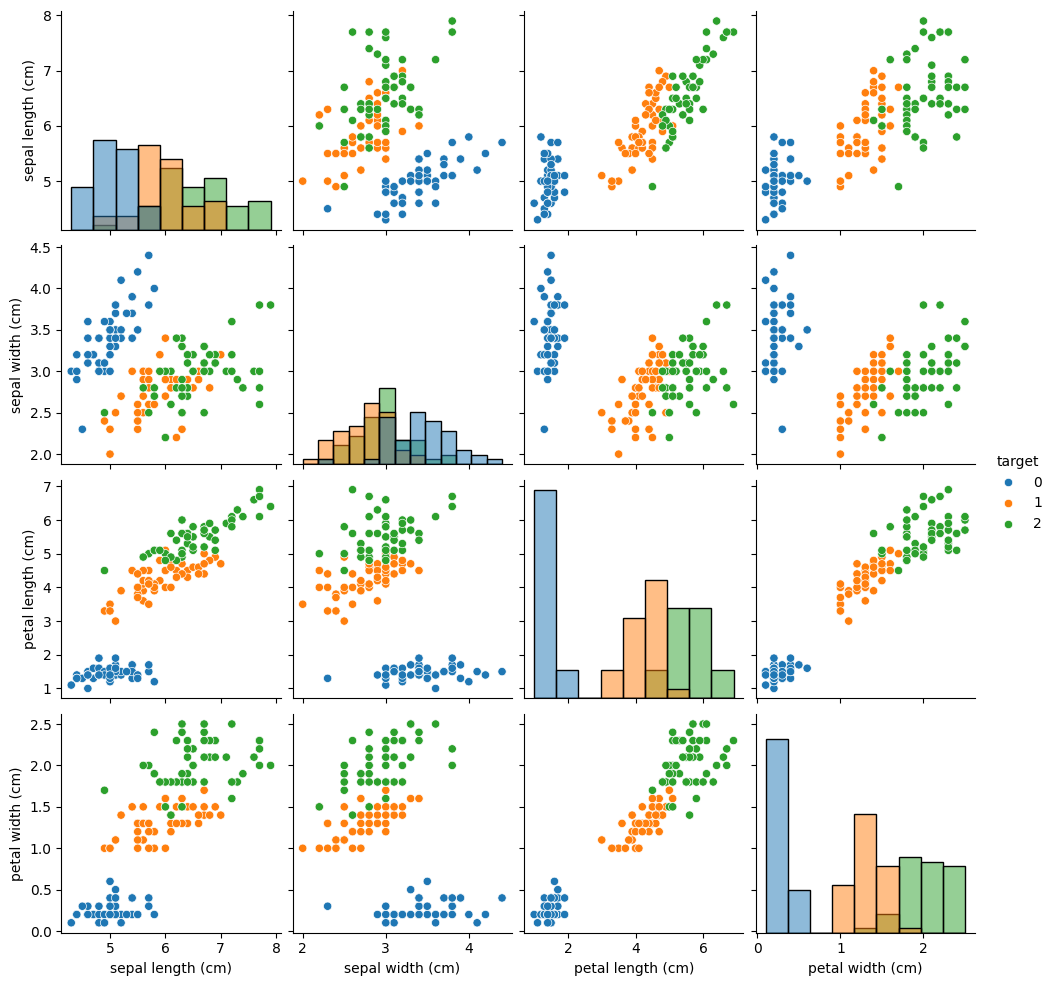

In [ ]:
sns.pairplot(df, hue='target', palette= "tab10", diag_kind='hist')

4. Виконати стандартизацію даних:

In [ ]:
X = df.iloc[:, :-2]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


5. Виконати спектральну кластеризація:

In [ ]:
#spectral = SpectralClustering(n_clusters=3,affinity='rbf',random_state=42)
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42)
clusters = spectral.fit_predict(X_scaled)
df['cluster'] = clusters

6. Порівняти спрогнозовані кластери та дійсні класи:

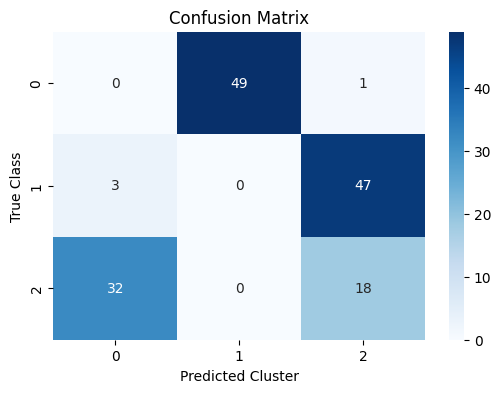

In [ ]:
cm = confusion_matrix(df['target'], df['cluster'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Cluster")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

7. Візуалізувати результати кластеризації:

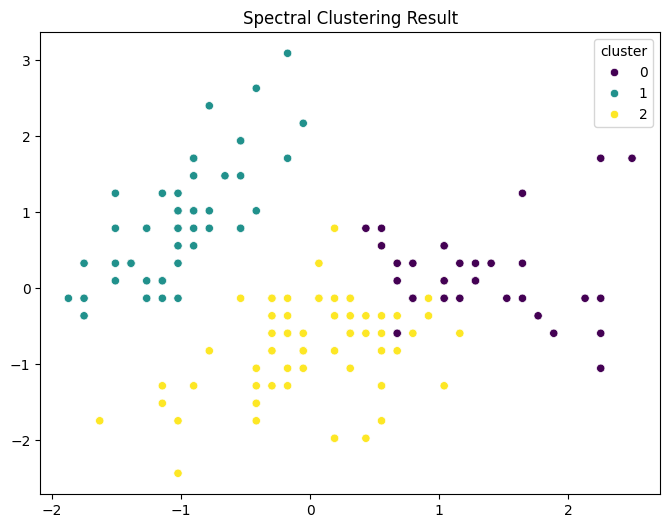

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=df['cluster'],
    palette='viridis'
)
plt.title("Spectral Clustering Result")
plt.show()

Висновок:

Спектральна кластеризація показала високу ефективність у виділенні класу Setosa та часткове змішування Versicolor і Virginica через їх близькі характеристики. Стандартизація суттєво покращила результат. Confusion Matrix підтвердила логічність отриманих кластерів. Метод продемонстрував здатність виявляти природну структуру даних, але має обмеження при перекриванні класів.

АНАЛІТИЧНІ ВИСНОВКИ ДО ЗАВДАННЯ
1) Первинний аналіз даних
Датасет містить 150 спостережень і 4 числові ознаки.
Класи збалансовані (по 50 об'єктів кожного виду).
Візуалізація показала, що Setosa добре відокремлюється, тоді як Versicolor і Virginica частково перекриваються.
Це означає, що повна ідеальна кластеризація буде складною.

2) Стандартизація
Ознаки мають різні масштаби.
Після StandardScaler середнє ≈ 0, стандартне відхилення ≈ 1.
Без стандартизації алгоритм був би зміщений у бік ознак із більшими значеннями.
Стандартизація була критично необхідною.

3) Результати Spectral Clustering
Алгоритм коректно виділив один чіткий кластер (Setosa).
Часткове змішування відбулося між Versicolor і Virginica.
Це логічно, оскільки ці два види мають близькі характеристики.
Spectral Clustering добре працює, але не магічно розділяє перекривані дані.

4) Аналіз Confusion Matrix
Висока точність для класу Setosa.
Помилки зосереджені між Versicolor і Virginica.
Це підтверджує, що геометрично ці два класи близькі.
Confusion Matrix підтвердила результати візуального аналізу.

5) Сильні сторони методу
Працює з нелінійними межами.
Ефективний для складної структури даних.
Не потребує міток (unsupervised).

6) Обмеження
Чутливий до параметрів (gamma, affinity).
Обчислювально дорожчий за KMeans.
Потребує правильної стандартизації.


Головний висновок:

Spectral Clustering успішно виявляє природну структуру Iris,
особливо добре відокремлює Setosa,
але має труднощі з частково перекриваними класами.
Результати узгоджуються з візуальним аналізом ознак.